In [15]:
from CONFIG import *
from dataloader import BgRemovalDataset
from model import Unet
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from loss import LossFn

In [5]:
train_dataset = BgRemovalDataset(
    real_img_path=REAL_IMG_PATH,
    mask_img_path=MASK_IMG_PATH,
    crop_size=512
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

In [7]:
img, mask = next(iter(train_dataloader))

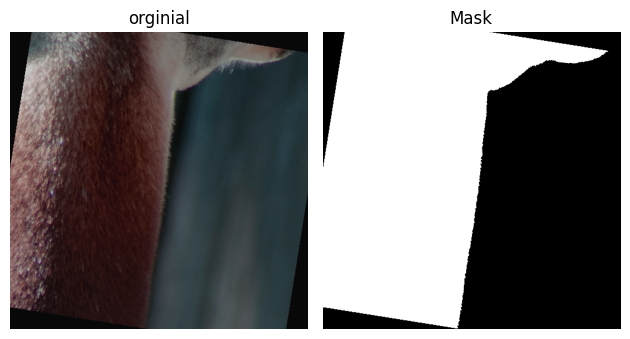

In [ ]:
from matplotlib import pyplot as plt

plt.subplot(1, 2, 1)
plt.title('orginial')
plt.imshow(img[0].permute(1, 2, 0))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Mask')
plt.imshow(mask[0].permute(1, 2, 0), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [19]:
model = Unet(in_ch=IN_CH, out_ch=OUT_CH).to(DEVICE)

In [20]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [36]:
scaler = torch.amp.GradScaler('cuda')

for epoch in range(EPOCHS):

    model.train()
    loader = tqdm(train_dataloader, desc='Training')

    for img, mask in loader:
        img = img.to(DEVICE)
        mask = mask.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            pred = model(img)
            loss = loss_fn(pred, mask)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loader.set_postfix(loss=float(loss))

Training:   0%|          | 0/125 [00:00<?, ?it/s]


AssertionError: No inf checks were recorded for this optimizer.

In [24]:
torch.save(model.state_dict(), 'unet_20.pth')

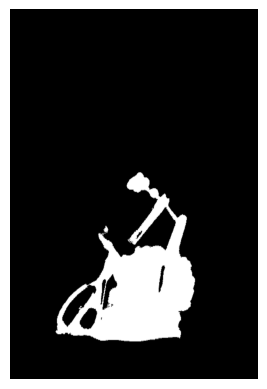

In [31]:
#write inference code here
from torchvision import transforms
from PIL import Image

test_img = Image.open(r"D:\coding\python_projects\pytorch\rembg\dataset\original\o_0b376f13.jpg").convert('RGB')
size = test_img.size
test_img = test_img.resize((512, 512))
test_img_tensor = transforms.ToTensor()(test_img).unsqueeze(0).to(DEVICE)

model = Unet(in_ch=IN_CH, out_ch=OUT_CH).to(DEVICE)
model.load_state_dict(torch.load('unet_20.pth'))

model.eval()
with torch.no_grad():
    pred_mask = model(test_img_tensor)
    pred_mask = torch.sigmoid(pred_mask).squeeze().cpu().numpy()

pred_mask = (pred_mask > 0.5).astype('uint8') * 255
pred_mask = Image.fromarray(pred_mask).resize(size)
plt.imshow(pred_mask, cmap='gray')
plt.axis('off')
plt.show()

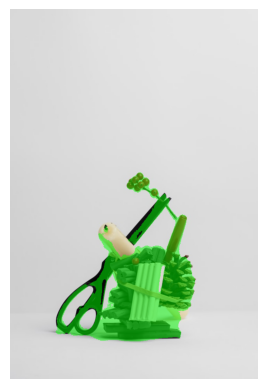

In [35]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


orig_img = Image.open(r"D:\coding\python_projects\pytorch\rembg\dataset\original\o_0b376f13.jpg").convert('RGB')
# Convert to numpy
orig_np = np.array(orig_img)
mask_np = np.array(mask)

# Binary mask (0 or 1)
mask_bin = (mask_np > 127).astype(np.uint8)

# Create green layer
green = np.zeros_like(orig_np)
green[:, :, 1] = 255   # Full Green channel

# Blend strength (adjustable)
alpha = 0.5  # 0 = original, 1 = full green

# Overlay only where mask == 1
overlay_np = orig_np.copy()
overlay_np[mask_bin == 1] = (
    (1 - alpha) * orig_np[mask_bin == 1] +
    alpha * green[mask_bin == 1]
)

overlay_img = Image.fromarray(overlay_np.astype(np.uint8))

plt.imshow(overlay_img)
plt.axis("off")
plt.show()